In [1]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
from astropy.table import Table
from mgefit.mge_fit_sectors import mge_fit_sectors
from mgefit.mge_fit_sectors_regularized import mge_fit_sectors_regularized
from mgefit.find_galaxy import find_galaxy
from mgefit.sectors_photometry import sectors_photometry
from mgefit.mge_print_contours import mge_print_contours, _gauss2d_mge
from mgefit.mge_print_contours_twist import mge_print_contours_twist
import astropy.io.fits as fits
import matplotlib

from mgefit.sectors_photometry_twist import sectors_photometry_twist
from mgefit.mge_fit_sectors_twist import mge_fit_sectors_twist

import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals/')

from IO_data import extract_Pipe3d_data, extract_data

In [2]:
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [3]:
PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
VEL_FOLDER = DATA_FOLDER + 'DR17/'
master_table_fn = DATA_FOLDER + 'output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_v2.fits'

In [4]:
master_table = Table.read(master_table_fn)
master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64

In [5]:
master_table_dict = {}
for i in range(len(master_table)):
    master_table_dict[master_table['plateifu'][i]] = i

In [6]:
test_gal = '8319-1902'
idx = master_table_dict[test_gal]
sMass_maps = extract_Pipe3d_data(PIPE3D_FOLDER, test_gal, ['sMass'])
flux_maps = extract_data(VEL_FOLDER, test_gal, ['flux'])
PA = master_table[idx]['nsa_elpetro_phi']
ba = master_table[idx]['nsa_elpetro_ba']

In [7]:
sMass = sMass_maps['sMass_density']
flux = flux_maps['mflux']
mask = np.logical_or(np.isnan(sMass), sMass == 0)
msMass = ma.array(sMass, mask = mask)
fmask = flux <= 0
mflux = ma.array(flux, mask=fmask)
x0, y0 = np.where(flux == np.max(flux))[1][0], np.where(flux == np.max(flux))[0][0] 

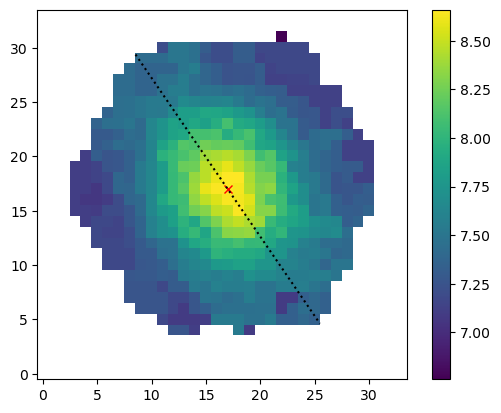

In [8]:
plt.imshow(msMass)
plt.plot(x0, y0, marker='x', color='r')
plt.plot([x0-15*np.sin(PA*np.pi/180),x0-15*np.sin((PA+180)*np.pi/180)],
         [y0+15*np.cos(PA*np.pi/180), y0+15*np.cos((PA+180)*np.pi/180)], color='k', linestyle=':')
plt.gca().invert_yaxis()
plt.colorbar()

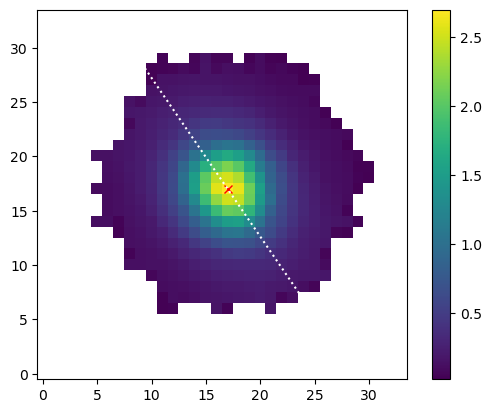

In [9]:
plt.imshow(mflux)
plt.plot(x0, y0, marker='x', color='r')
plt.plot([x0-15*np.sin(PA*np.pi/180),x0-15*np.sin((PA+180)*np.pi/180)],
         [y0+15*np.cos(PA*np.pi/180), y0+15*np.cos((PA+180)*np.pi/180)], color='white', linestyle=':')
plt.gca().invert_yaxis()
plt.colorbar()

## test with no twists on flux map

 Pixels used: 116
 Peak Img[j, k]: 17 17
 Mean (j, k): 17.02 17.14
 Theta (deg): 54.4
 Astro PA (deg): 35.6
 Eps: 0.092
 Major axis (pix): 6.4


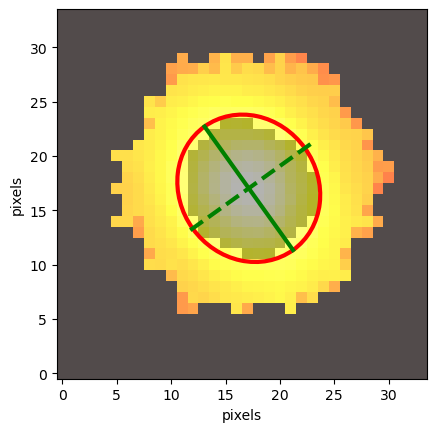

In [51]:
f = find_galaxy(flux, fraction=0.1, plot=True)

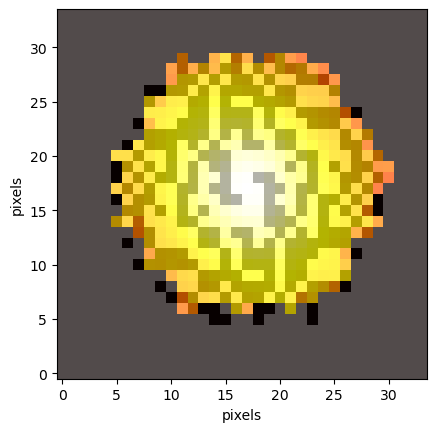

In [52]:
s = sectors_photometry(flux, f.eps, f.theta, f.xpeak, f.ypeak,
                            plot=1, minlevel=0.01)

Starting the LINEAR fit with  10000  Gaussians. Please wait...
Nonzero Gaussians: 5/10000
Eliminating not useful Gaussians...
ngauss: 4          chi2: 12.72
ngauss: 3          chi2: 12.72
Starting nonlinear fit...
Iteration: 0  chi2: 12.72  Nonzero: 3/3
Iteration: 2  chi2: 12.72  Nonzero: 3/3
Nonzero Gaussians: 3/3
Eliminating not useful Gaussians...
All Gaussians are needed!
############################################
  Computation time: 0.63 seconds
  Total Iterations:  0
 Nonzero Gaussians:  3
  Unused Gaussians:  9997
 Sectors used in the fit:  19
 Total number of points fitted:  192
 Chi2: 12.72 
 STDEV: 0.2487 
 MEANABSDEV: 0.1692 
############################################
  Total_Counts   sigma_Pixels     q_obs
############################################
   2.6106e+01        1.822       1.0000
   1.9858e+01        4.221       0.4493
   1.4443e+02        4.473       1.0000
++++++++++++++++++++++++++++++++++++++++++++


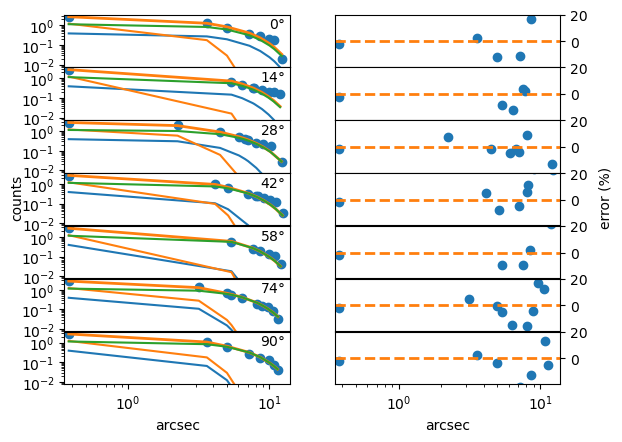

In [53]:
m = mge_fit_sectors(s.radius, s.angle, s.counts, f.eps,
                        ngauss=None, plot=1, bulge_disk=0, linear=1)

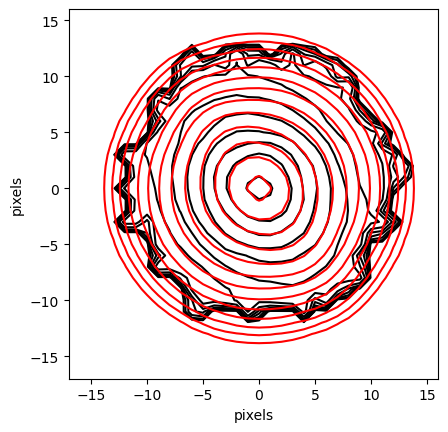

In [54]:
mge_print_contours(flux, f.theta, f.xpeak, f.ypeak, m.sol, 
                   #scale=0.25,
                       #sigmapsf=sigmapsf, normpsf=normpsf, binning=9, 
                       minlevel=0.01
                  )

(-2.0, 2.0)

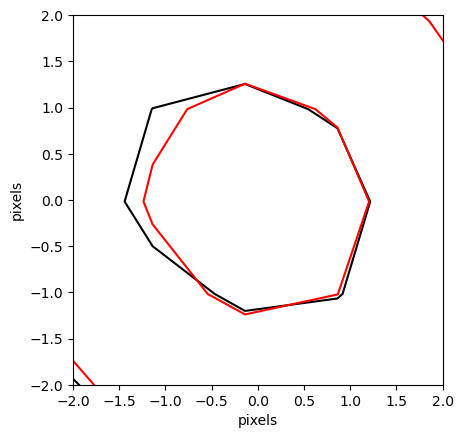

In [55]:
mge_print_contours(flux, f.theta, f.xmed, f.ymed, m.sol, 
                   #scale=0.25, 
                       #sigmapsf=sigmapsf, normpsf=normpsf
                  )
plt.xlim(-2, 2)
plt.ylim(-2, 2)


In [56]:
L, sigma, q = m.sol

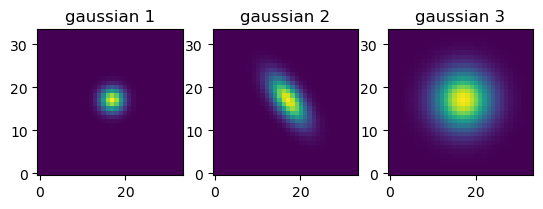

In [57]:
fig,ax = plt.subplots(1,3)

for i in range(3):
    ax[i].imshow(L[i]/(2*np.pi*sigma[i]**2 * q[i])*_gauss2d_mge(flux.shape, f.xpeak, f.ypeak, sigma[i], sigma[i]*q[i], f.theta))
    ax[i].set_title('gaussian ' + str(i+1))
    ax[i].invert_yaxis()

In [58]:
mge_flux=0.
for i in range(len(L)):
    mge_flux += L[i]/(2*np.pi*sigma[i]**2 * q[i]) *_gauss2d_mge(flux.shape, f.xpeak, f.ypeak, sigma[i], sigma[i]*q[i], f.pa)


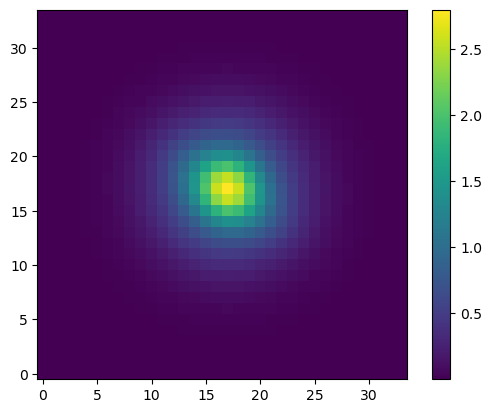

In [59]:
plt.imshow(mge_flux)
plt.gca().invert_yaxis()
plt.colorbar()

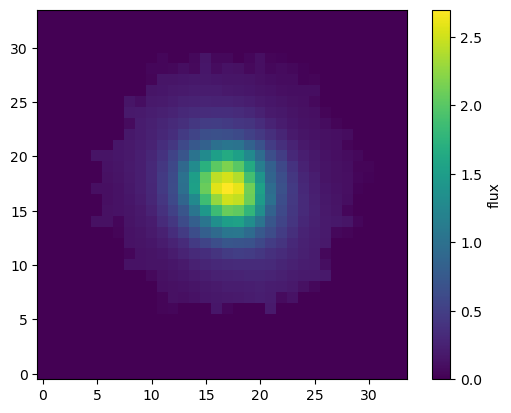

In [60]:
plt.imshow(flux)
plt.gca().invert_yaxis()
plt.colorbar(label='flux')

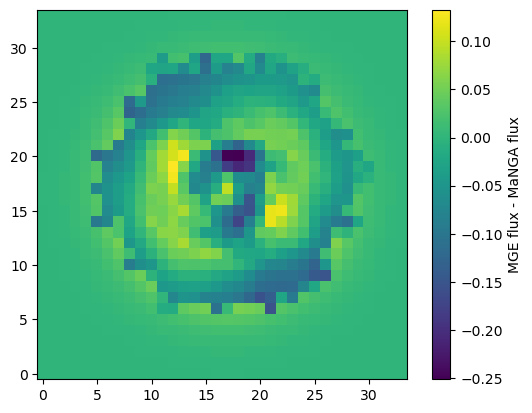

In [61]:
plt.imshow(mge_flux - flux)
plt.colorbar(label='MGE flux - MaNGA flux')
plt.gca().invert_yaxis()


/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_49028/612937420.py:2: RuntimeWarning: divide by zero encountered in divide
  plt.imshow((mge_flux - flux)/flux)


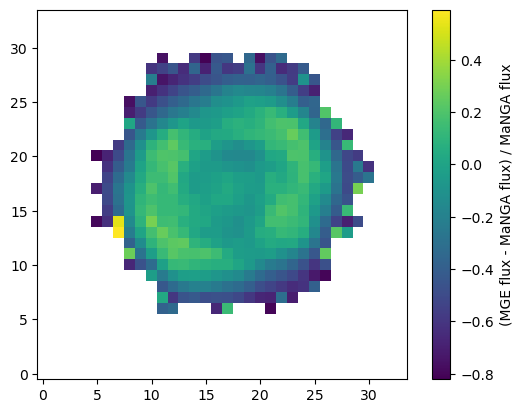

In [62]:
# relative residula
plt.imshow((mge_flux - flux)/flux)
plt.colorbar(label='(MGE flux - MaNGA flux) / MaNGA flux')
plt.gca().invert_yaxis()

In [63]:
## using gaussian 2 to figure out how to rotate map

g2 = L[1]/(2*np.pi*sigma[1]**2 * q[1]) *_gauss2d_mge(flux.shape, f.xpeak, f.ypeak, sigma[1], sigma[i]*q[1], f.theta)


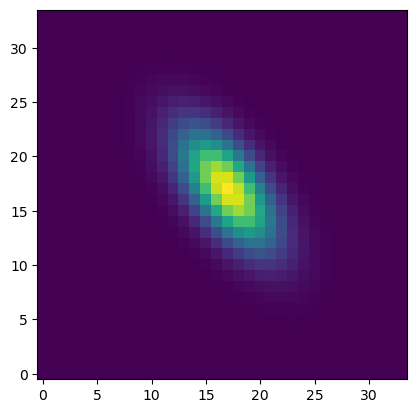

In [64]:
plt.imshow(g2)
plt.gca().invert_yaxis()

In [23]:
center = (f.xpeak, f.ypeak)
im_axis = np.linspace(0, len(g2), len(g2) +1)
dist_x, dist_y = im_axis - f.xpeak, im_axis-f.ypeak
xs, ys = np.meshgrid(dist_x, dist_y)

rot_xs = xs*np.cos(np.radians(f.theta)) - ys*np.sin(np.radians(f.theta))
rot_ys = xs*np.sin(np.radians(f.theta)) + ys*np.cos(np.radians(f.theta))

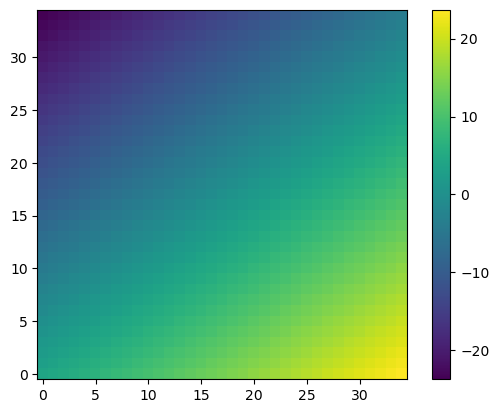

In [24]:
plt.imshow(rot_xs)
plt.gca().invert_yaxis()
plt.colorbar()

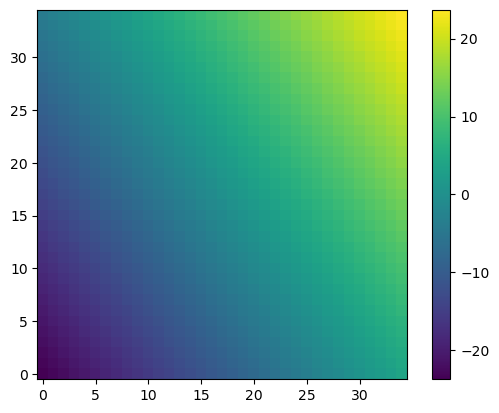

In [25]:
plt.imshow(rot_ys)
plt.gca().invert_yaxis()
plt.colorbar()

Text(0.5, 0, 'MGE flux - MaNGA flux')

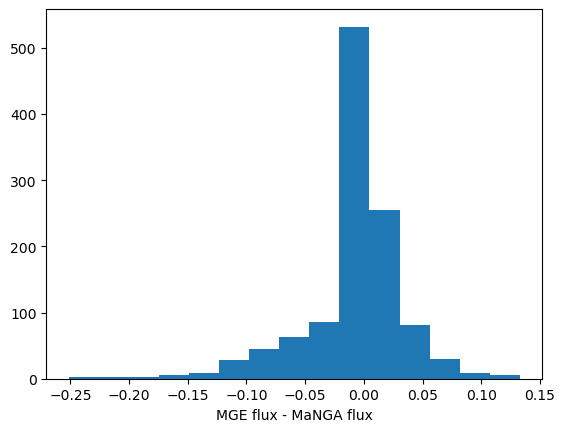

In [82]:
plt.hist((mge_flux - flux).flatten(), bins=15)
plt.xlabel('MGE flux - MaNGA flux')

Text(0.5, 0, '(MGE flux - MaNGA flux) / MaNGA flux')

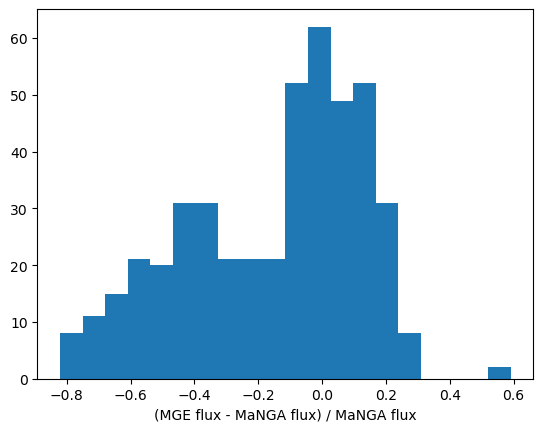

In [83]:
plt.hist((mge_flux[flux>0] - flux[flux>0])/flux[flux>0], bins=20)
plt.xlabel('(MGE flux - MaNGA flux) / MaNGA flux')

## smass test without twitsts

 Pixels used: 116
 Peak Img[j, k]: 17 17
 Mean (j, k): 17.02 17.14
 Theta (deg): 54.4
 Astro PA (deg): 35.6
 Eps: 0.092
 Major axis (pix): 6.4


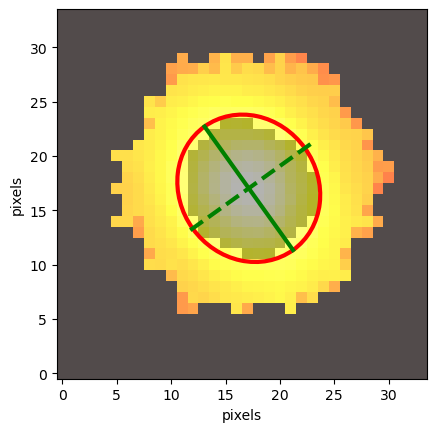

In [171]:
# using photometry from flux map
f = find_galaxy(flux, fraction=0.1, plot=1)

In [172]:
sMass[mask]=0

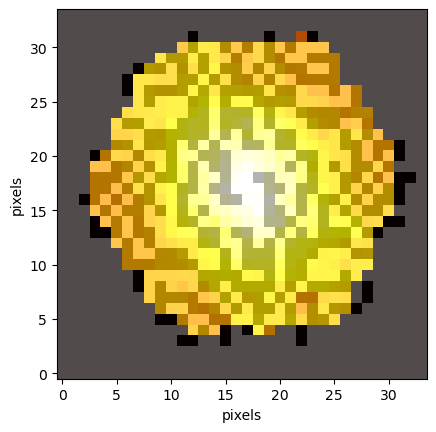

In [173]:
s = sectors_photometry(10**sMass, f.eps, f.theta, f.xpeak, f.ypeak,
                            plot=1, minlevel=6, #mask=sMass==0
                      )

Starting the LINEAR fit with  10000  Gaussians. Please wait...
Nonzero Gaussians: 10/10000
Eliminating not useful Gaussians...
ngauss: 9          chi2: 12.52
ngauss: 8          chi2: 12.52
ngauss: 7          chi2: 12.52
ngauss: 6          chi2: 12.52
ngauss: 5          chi2: 12.52
ngauss: 4          chi2: 12.56
Starting nonlinear fit...
Iteration: 0  chi2: 12.56  Nonzero: 4/4
Iteration: 4  chi2: 12.53  Nonzero: 4/4
Nonzero Gaussians: 4/4
Eliminating not useful Gaussians...
All Gaussians are needed!
############################################
  Computation time: 1.04 seconds
  Total Iterations:  0
 Nonzero Gaussians:  4
  Unused Gaussians:  9996
 Sectors used in the fit:  19
 Total number of points fitted:  218
 Chi2: 12.53 
 STDEV: 0.2327 
 MEANABSDEV: 0.1633 
############################################
  Total_Counts   sigma_Pixels     q_obs
############################################
   1.0268e+10        2.452       0.8639
   1.9012e+10        5.803       1.0000
   3.8892e+09     

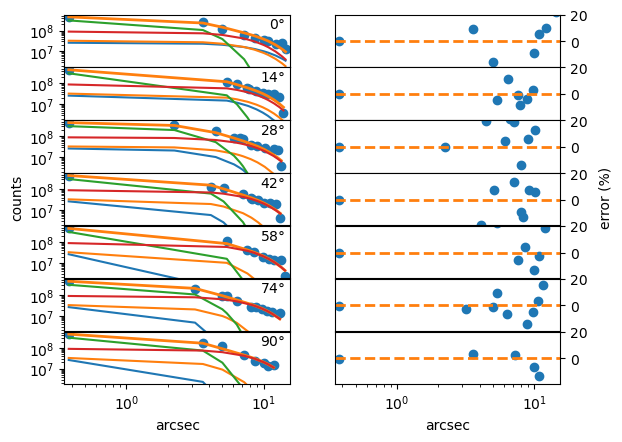

In [174]:
m = mge_fit_sectors(s.radius, s.angle, s.counts, f.eps,
                        ngauss=None, plot=1, bulge_disk=0, linear=1)

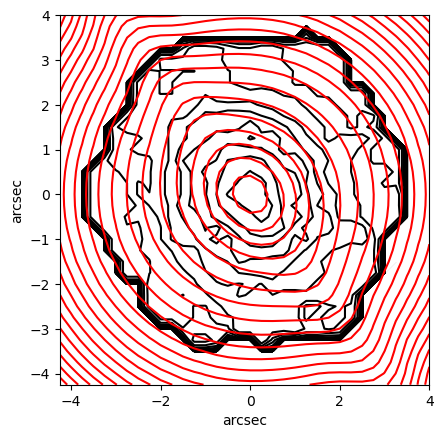

In [175]:
mge_print_contours(10**sMass, f.theta, f.xpeak, f.ypeak, m.sol, 
                   scale=0.25,
                       #sigmapsf=sigmapsf, normpsf=normpsf, binning=9, 
                       minlevel=6
                  )

In [177]:
L, sigma, q_obs = m.sol

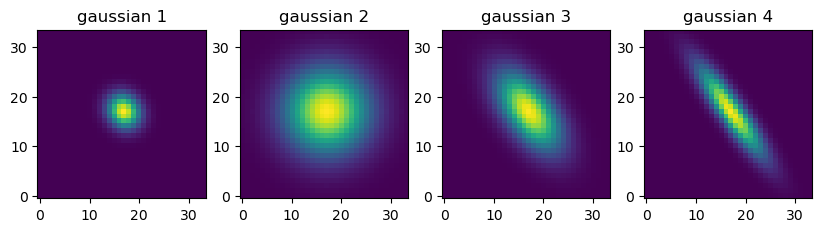

In [178]:
fig,ax = plt.subplots(1,4, figsize=(10,10))

for i in range(4):
    ax[i].imshow(L[i]/(2*np.pi*sigma[i]**2 * q_obs[i])*_gauss2d_mge(flux.shape, f.xpeak, f.ypeak, sigma[i], sigma[i]*q_obs[i], f.theta))
    ax[i].set_title('gaussian ' + str(i+1))
    ax[i].invert_yaxis()



In [179]:
mge_flux=0.
for i in range(len(L)):
    mge_flux += L[i]/(2*np.pi*sigma[i]**2 * q_obs[i]) *_gauss2d_mge(flux.shape, f.xpeak, f.ypeak, sigma[i], sigma[i]*q_obs[i], f.theta)

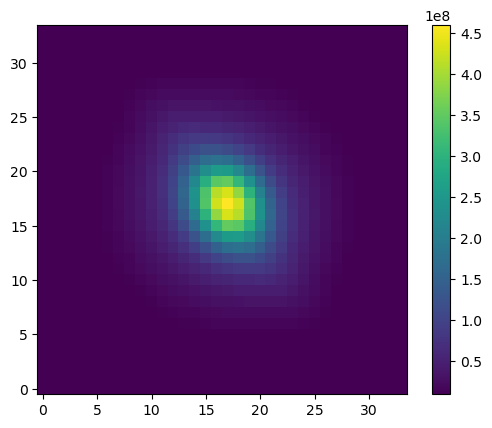

In [180]:
plt.imshow(mge_flux, vmin=10**7, vmax=4.6*10**8)
plt.colorbar()
plt.gca().invert_yaxis()

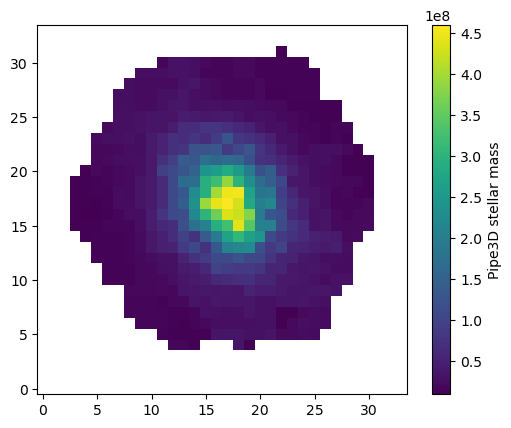

In [181]:
plt.imshow(10**msMass, vmin=10**7, vmax=4.6*10**8)
plt.colorbar(label='Pipe3D stellar mass')
plt.gca().invert_yaxis()

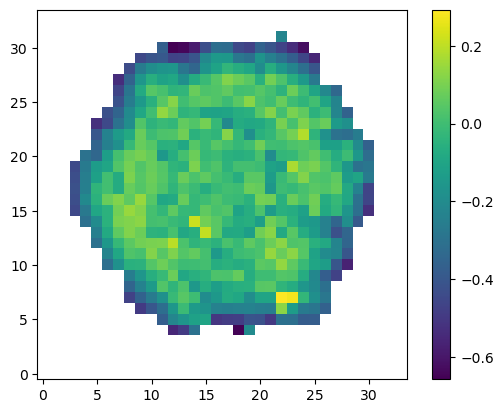

In [182]:
plt.imshow(np.log10(mge_flux) - msMass)
plt.colorbar()
plt.gca().invert_yaxis()

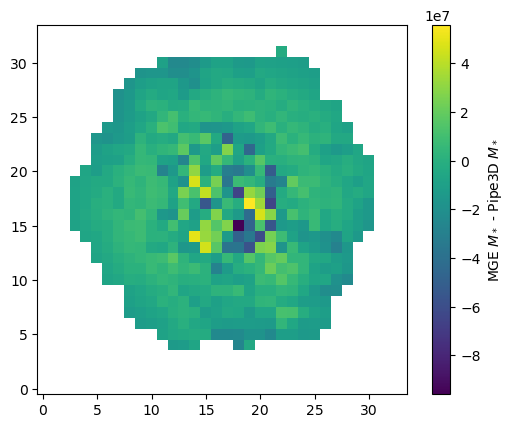

In [183]:
plt.imshow(mge_flux - 10**msMass)
plt.colorbar(label='MGE $M_*$ - Pipe3D $M_*$')
plt.gca().invert_yaxis()

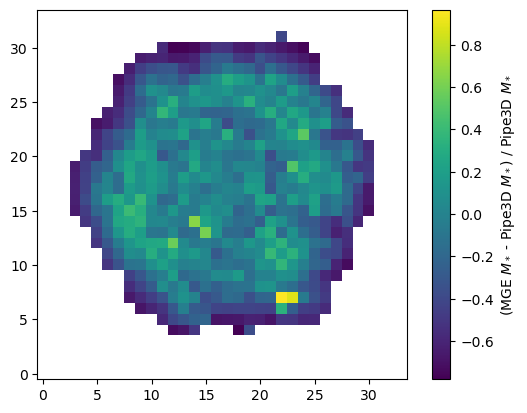

In [184]:
plt.imshow((mge_flux - 10**msMass)/10**sMass)
plt.colorbar(label='(MGE $M_*$ - Pipe3D $M_*$) / Pipe3D $M_*$')
plt.gca().invert_yaxis()

In [186]:
array_length = msMass.shape[0]  # y-coordinate distance
array_width = msMass.shape[1]  # x-coordinate distance

X_RANGE = np.arange(0, array_width, 1)
Y_RANGE = np.arange(0, array_length, 1)
X_COORD, Y_COORD = np.meshgrid( X_RANGE, Y_RANGE)
############################################################################


############################################################################
# Initialization code to draw the elliptical annuli.
#---------------------------------------------------------------------------
phi_elip = (90 - f.theta)*np.pi/180.

x_diff = X_COORD - f.xpeak
y_diff = Y_COORD - f.ypeak

ellipse = (x_diff*np.cos(phi_elip) - y_diff*np.sin(phi_elip))**2 \
          + (x_diff*np.sin(phi_elip) + y_diff*np.cos(phi_elip))**2 \
          / ba**2

In [ ]:
radius = []

sMass_interior_curve = []
sMass_interior_curve_err = []
############################################################################


############################################################################
# Initialize the stellar mass surface density interior to an annulus to
# be 0 solar masses.
#---------------------------------------------------------------------------
sMass_interior = 0.
sMass_interior_err2 = 0.
sMass_interior_err = 0.
############################################################################


############################################################################
#---------------------------------------------------------------------------
dR = 2
R = 2

while True:

    deproj_dist_kpc = R*pix_scale_factor

    ########################################################################
    # Define an eliptical annulus and check if there is at least one point 
    # within the mask.
    #-----------------------------------------------------------------------
    pix_between_annuli = np.logical_and( (R - dR)**2 <= ellipse, 
                                         ellipse < R**2)

    if not np.any( map_mask[ pix_between_annuli] == 0):
        break
    ########################################################################


    ########################################################################
    # Extract the stellar mass interior to that annulus.
    #-----------------------------------------------------------------------
    sMass_interior, sMass_interior_err2 = calc_stellar_mass(sMass_interior,
                                        sMass_interior_err2,
                                       10**msMass_density, 
                                       10**msMass_density_err,
                                       pix_between_annuli)

    sMass_interior_err = np.sqrt(sMass_interior_err2)
    
    ########################################################################


    ########################################################################
    # Append the corresponding values to their respective arrays to write to 
    # the output data file.
    #-----------------------------------------------------------------------
    if np.isfinite(sMass_interior):
        radius.append( deproj_dist_kpc)

        sMass_interior_curve.append( np.log10(sMass_interior))
        sMass_interior_curve_err.append( np.log10(sMass_interior_err))
    ########################################################################


    ########################################################################
    # Increment the radius of the annulus R by dR
    #-----------------------------------------------------------------------
    R += dR

Text(0.5, 0, 'MGE $M_*$ - Pipe3D $M_*$')

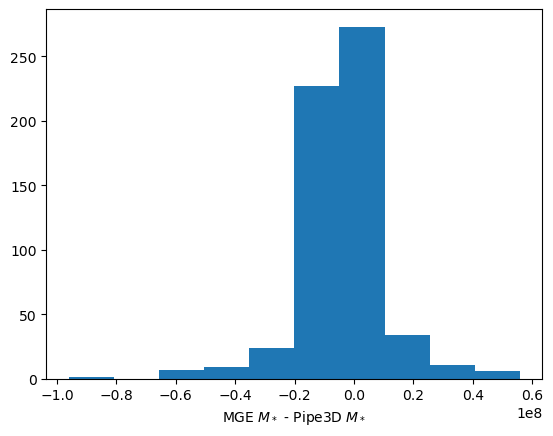

In [121]:
plt.hist((mge_flux[sMass>0]-10**sMass[sMass>0]).flatten(), bins=10)
plt.xlabel(r'MGE $M_*$ - Pipe3D $M_*$')

Text(0.5, 0, '(MGE $M_*$ - Pipe3D $M_*$)/Pipe3D $M_*$')

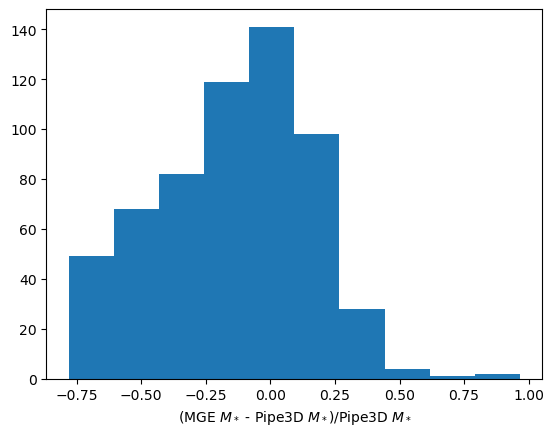

In [125]:
plt.hist(((mge_flux[sMass>0]-10**sMass[sMass>0])/10**sMass[sMass>0]).flatten(), bins=10)
plt.xlabel(r'(MGE $M_*$ - Pipe3D $M_*$)/Pipe3D $M_*$')

In [40]:
(np.sum(L) - 10**master_table[master_table_dict[test_gal]]['sphd_M_star'])/10**master_table[master_table_dict[test_gal]]['sphd_M_star']

-0.08998235942310794

In [41]:
np.log10(10**master_table[master_table_dict[test_gal]]['sphd_M_star'] - np.sum(L))

9.5407578496326

In [42]:
np.log10(np.sum(L))

10.54565028418539

In [43]:
master_table[master_table_dict[test_gal]]['sphd_M_star']

10.586600473039082

## test on flux with twists

 Pixels used: 116
 Peak Img[j, k]: 17 17
 Mean (j, k): 17.02 17.14
 Theta (deg): 54.4
 Astro PA (deg): 35.6
 Eps: 0.092
 Major axis (pix): 6.4


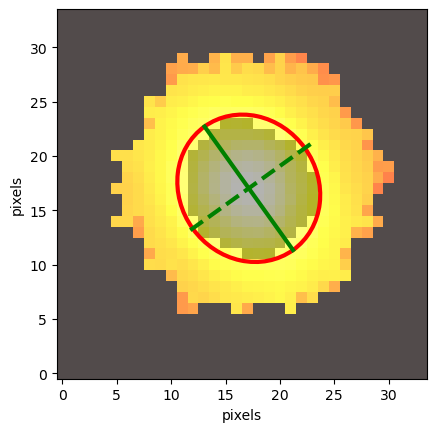

In [128]:
f = find_galaxy(flux, fraction=0.1, plot=True)

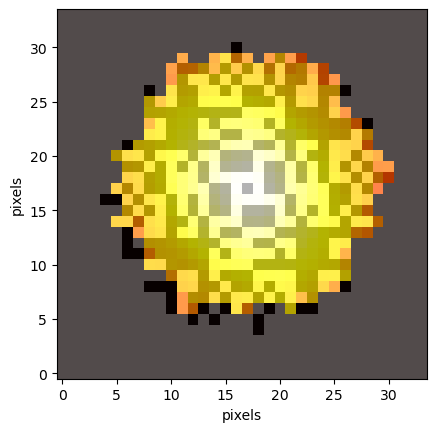

In [129]:
s = sectors_photometry_twist(img=flux, ang=f.theta, xc=f.xpeak, yc=f.ypeak,
                            plot=1, minlevel=0.01)

Iteration: 0  chi2: 24.42  Nonzero: 4/12
Iteration: 10  chi2: 23.30  Nonzero: 2/12
Iteration: 11  chi2: 23.30  Nonzero: 2/12
############################################
CapFit Terminating on small function variation (ftol), status: 2
  Computation time: 0.21 seconds
  Total Iterations:  11
 Nonzero Gaussians:  2
  Unused Gaussians:  10
 Sectors used in the fit:  36
 Total number of points fitted:  264
 Chi2: 23.30 
 STDEV: 0.2837 
 MEANABSDEV: 0.1998 
#####################################################
  Total_Counts   Sigma_Pixels     q_obs        PA
#####################################################
   3.1355e+01        2.012       0.8431     -22.73
   1.5716e+02        4.464       0.9526      -4.41
+++++++++++++++++++++++++++++++++++++++++++++++++++++


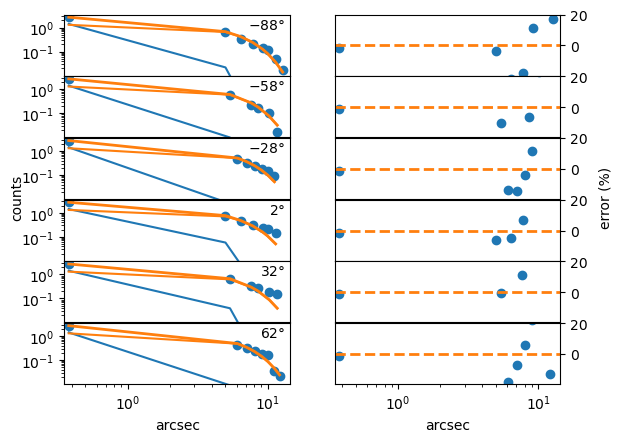

In [130]:
m = mge_fit_sectors_twist(s.radius, s.angle, s.counts, f.eps,
                        ngauss=None, plot=1,)

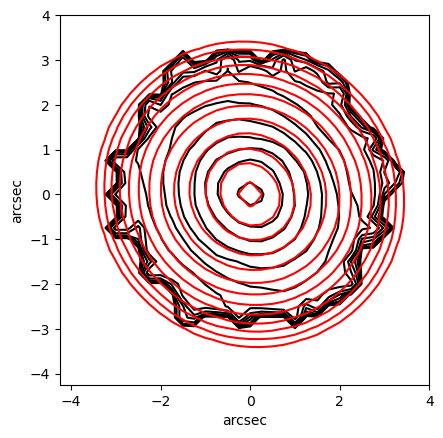

In [131]:
mge_print_contours_twist(flux, f.theta, f.xpeak, f.ypeak, m.sol, 
                   scale=0.25,
                       #sigmapsf=sigmapsf, normpsf=normpsf, binning=9, 
                       minlevel=0.01
                  )

In [132]:
L, sigma, q_obs, pa = m.sol

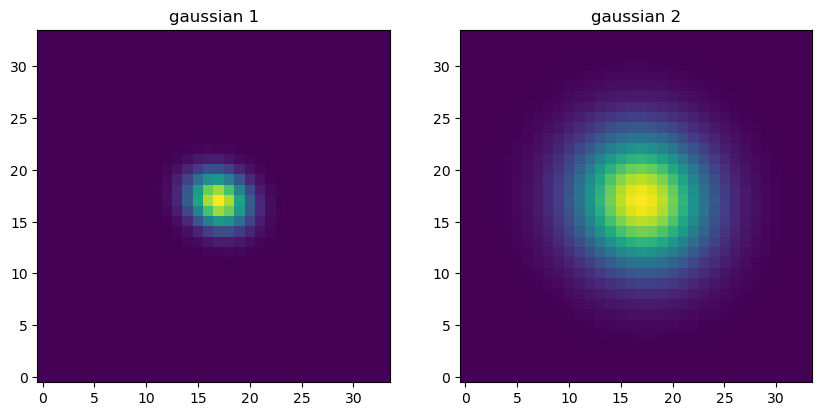

In [133]:
fig,ax = plt.subplots(1,2, figsize=(10,10))

for i in range(2):
    ax[i].imshow(L[i]/(2*np.pi*sigma[i]**2 * q_obs[i])*_gauss2d_mge(flux.shape, f.xpeak, f.ypeak, sigma[i], sigma[i]*q_obs[i], f.theta + pa[i]))
    ax[i].set_title('gaussian ' + str(i+1))
    ax[i].invert_yaxis()



In [134]:
mge_flux=0.
for i in range(len(L)):
    mge_flux += L[i]/(2*np.pi*sigma[i]**2 * q_obs[i]) *_gauss2d_mge(flux.shape, f.xpeak, f.ypeak, sigma[i], sigma[i]*q_obs[i], f.theta + pa[i])

In [135]:
np.sum(L/(2*np.pi*sigma**2 * q_obs))

2.779583729424211

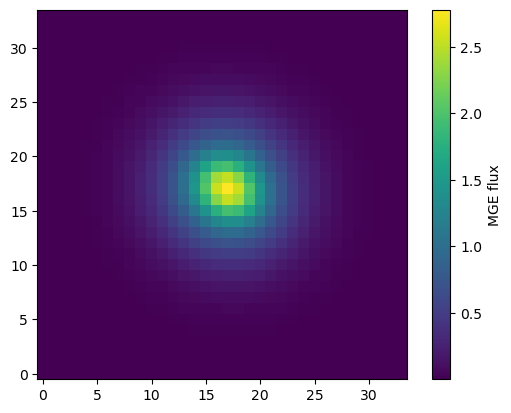

In [136]:
plt.imshow(mge_flux)
plt.colorbar(label='MGE flux')
plt.gca().invert_yaxis()

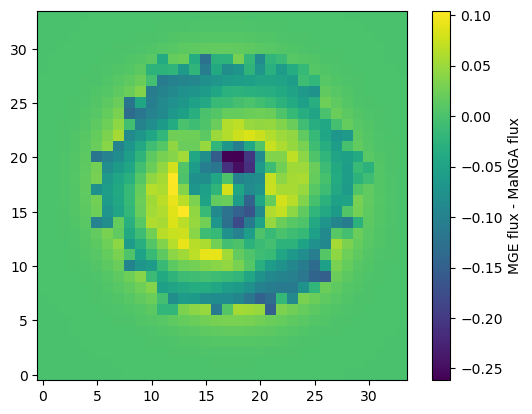

In [137]:
plt.imshow(mge_flux - flux)
plt.colorbar(label='MGE flux - MaNGA flux')
plt.gca().invert_yaxis()


/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_49028/3712076089.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.imshow((mge_flux - flux)/flux)


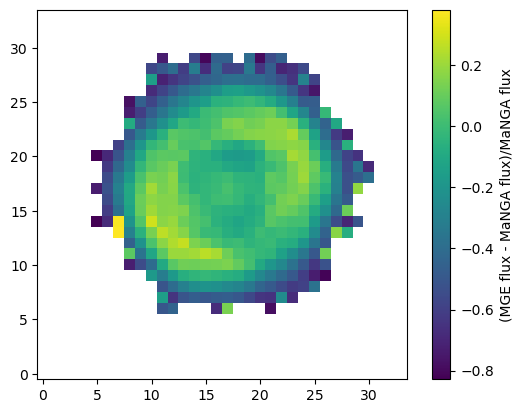

In [138]:
plt.imshow((mge_flux - flux)/flux)
plt.colorbar(label='(MGE flux - MaNGA flux)/MaNGA flux')
plt.gca().invert_yaxis()


Text(0.5, 0, 'MGE flux - MaNGA flux')

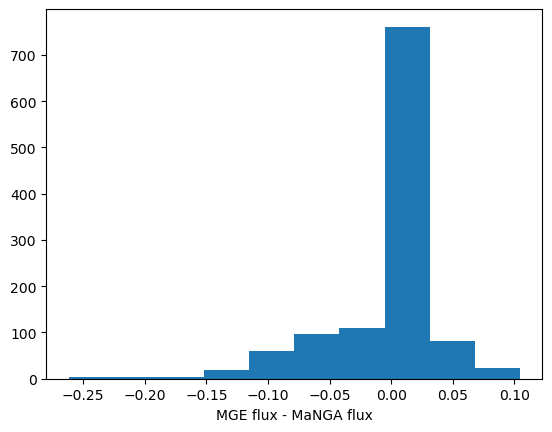

In [145]:
plt.hist((mge_flux - flux).flatten())
plt.xlabel('MGE flux - MaNGA flux')

Text(0.5, 0, 'MGE flux - MaNGA flux')

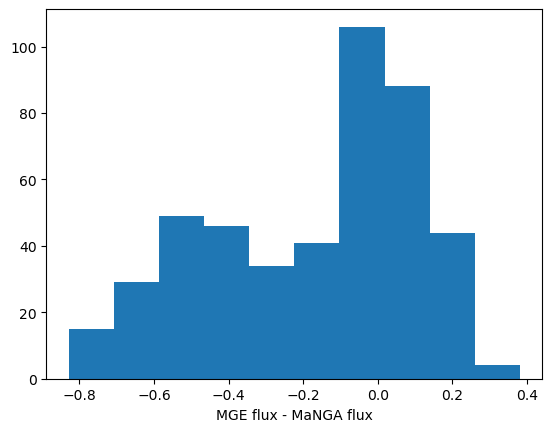

In [146]:
plt.hist((mge_flux[flux>0] - flux[flux>0])/flux[flux>0])
plt.xlabel('MGE flux - MaNGA flux')

## sMass test with twists

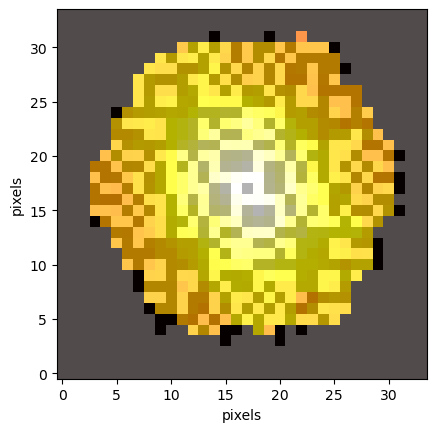

In [147]:
s = sectors_photometry_twist(img=10**sMass, ang=f.theta, xc=f.xpeak, yc=f.ypeak,
                            plot=1, minlevel=6,)

Iteration: 0  chi2: 24.93  Nonzero: 3/12
Iteration: 10  chi2: 20.34  Nonzero: 3/12
Iteration: 11  chi2: 20.34  Nonzero: 3/12
############################################
CapFit Terminating on small function variation (ftol), status: 2
  Computation time: 0.37 seconds
  Total Iterations:  11
 Nonzero Gaussians:  3
  Unused Gaussians:  9
 Sectors used in the fit:  36
 Total number of points fitted:  309
 Chi2: 20.34 
 STDEV: 0.2480 
 MEANABSDEV: 0.1685 
#####################################################
  Total_Counts   Sigma_Pixels     q_obs        PA
#####################################################
   4.9744e+09        2.192       0.9827      -0.24
   7.6887e+09        3.140       0.6429     -21.22
   2.2878e+10        6.505       0.8306     -18.33
+++++++++++++++++++++++++++++++++++++++++++++++++++++


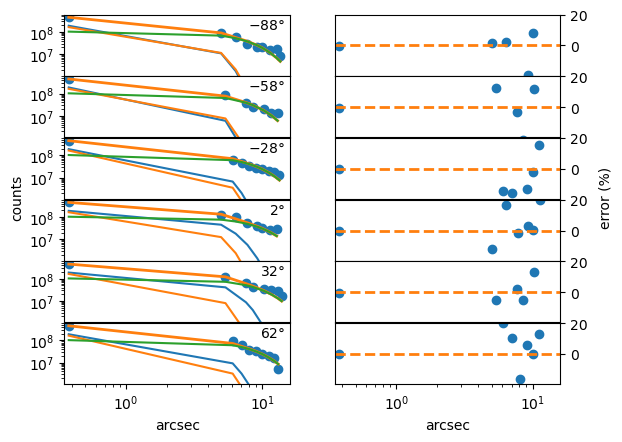

In [148]:
m = mge_fit_sectors_twist(s.radius, s.angle, s.counts, f.eps,
                        ngauss=None, plot=1, )

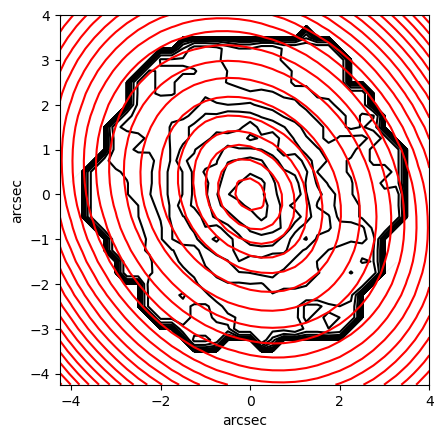

In [149]:
mge_print_contours_twist(10**sMass, f.theta, f.xpeak, f.ypeak, m.sol, 
                   scale=0.25,
                       #sigmapsf=sigmapsf, normpsf=normpsf, binning=9, 
                       minlevel=0.01
                  )

In [150]:
L, sigma, q_obs, pa = m.sol

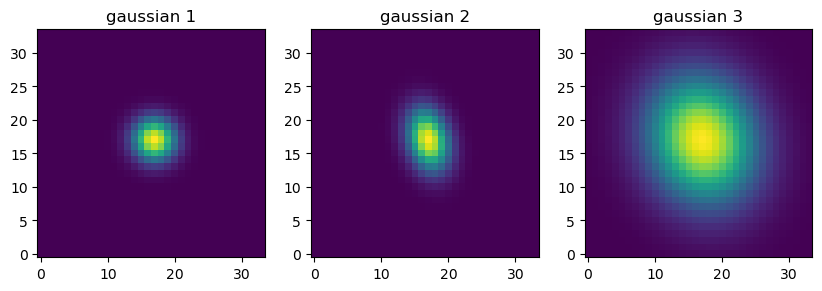

In [151]:
fig,ax = plt.subplots(1,3, figsize=(10,10))

for i in range(3):
    ax[i].imshow(L[i]/(2*np.pi*sigma[i]**2 * q_obs[i])*_gauss2d_mge(flux.shape, f.xpeak, f.ypeak, sigma[i], sigma[i]*q_obs[i], f.theta - pa[i]))
    ax[i].set_title('gaussian ' + str(i+1))
    ax[i].invert_yaxis()



In [152]:
mge_flux=0.
for i in range(len(L)):
    mge_flux += L[i]/(2*np.pi*sigma[i]**2 * q_obs[i]) *_gauss2d_mge(flux.shape, f.xpeak, f.ypeak, sigma[i], sigma[i]*q_obs[i], f.theta - pa[i])

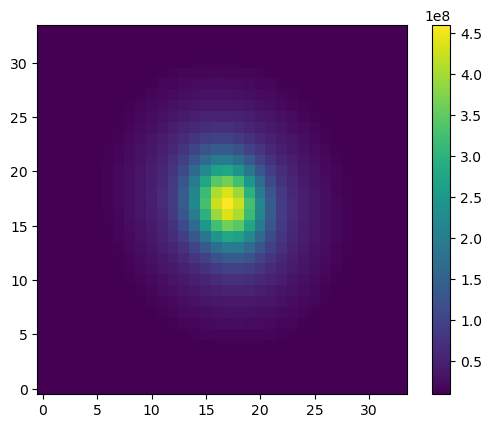

In [153]:
plt.imshow(mge_flux, vmin=10**7, vmax=4.6*10**8)
plt.colorbar()
plt.gca().invert_yaxis()

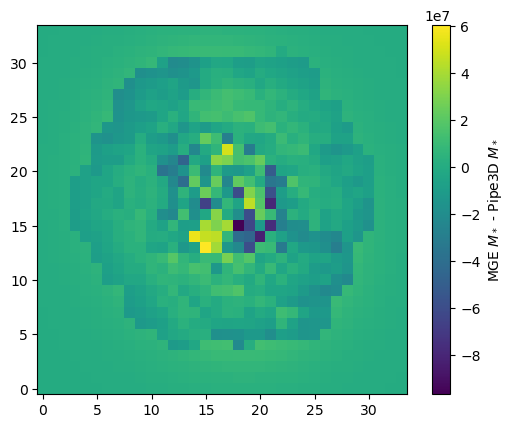

In [154]:
plt.imshow(mge_flux - 10** sMass)
plt.colorbar(label='MGE $M_*$ - Pipe3D $M_*$')
plt.gca().invert_yaxis()

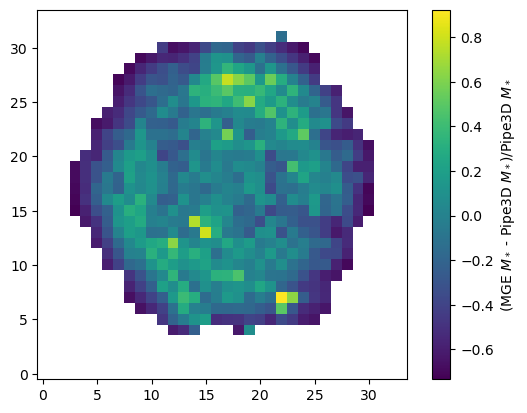

In [164]:
plt.imshow((ma.array(mge_flux, mask=[sMass==0]) - 10** ma.array(sMass, mask=[sMass==0]))/
           10**ma.array(sMass, mask=[sMass==0]))
plt.colorbar(label='(MGE $M_*$ - Pipe3D $M_*$)/Pipe3D $M_*$')
plt.gca().invert_yaxis()

Text(0.5, 0, 'MGE $M_*$ - Pipe3D $M_*$')

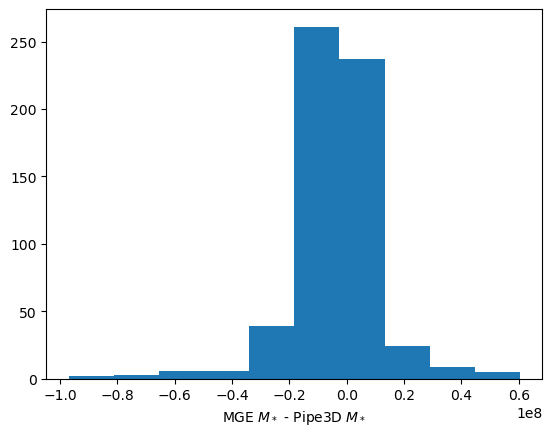

In [168]:
plt.hist(ma.array(mge_flux[sMass > 0] - 10**sMass[sMass>0]))
plt.xlabel(r'MGE $M_*$ - Pipe3D $M_*$')

Text(0.5, 0, '(MGE $M_*$ - Pipe3D $M_*$)/Pipe3D $M_*$')

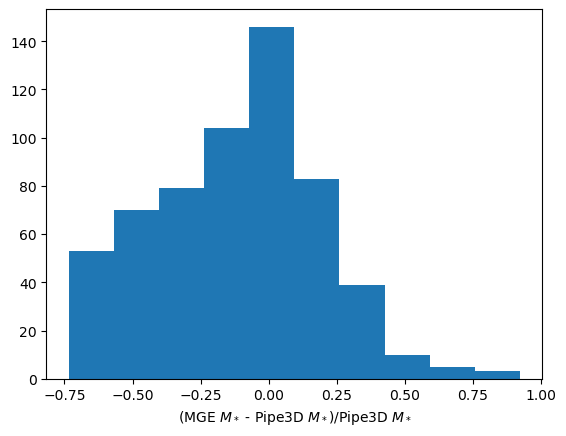

In [170]:
plt.hist((mge_flux[sMass > 0] - 10**sMass[sMass>0])/10**sMass[sMass>0])
plt.xlabel(r'(MGE $M_*$ - Pipe3D $M_*$)/Pipe3D $M_*$')

In [63]:
(np.sum(L) - 10**master_table[master_table_dict[test_gal]]['sphd_M_star'])/10**master_table[master_table_dict[test_gal]]['sphd_M_star']

-0.07928623614566455

In [64]:
master_table[master_table_dict[test_gal]]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64